**Mount Drive in Colab and install dependencies**

In [ ]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Clone the repo
import os
repo_path = '/content/darts-cards'
if not os.path.exists(repo_path):
    !git clone https://github.com/javiergarciaduran/darts-cards.git {repo_path}
else:
    !git -C {repo_path} pull
%cd {repo_path}

Mounted at /content/drive
Cloning into '/content/darts-cards'...
remote: Enumerating objects: 195, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 195 (delta 42), reused 61 (delta 35), pack-reused 110 (from 1)
Receiving objects: 100% (195/195), 11.64 MiB | 19.28 MiB/s, done.
Resolving deltas: 100% (86/86), done.
/content/darts-cards


In [ ]:
# 3. Install extra dependencies
!pip install -q graphviz wandb
!pip install tensorboardX
!apt-get install -q graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.7 MB/s eta 0:00:00
Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
# Convert to UTF-8 Encoding
!iconv -f UTF-16 -t UTF-8 /content/darts-cards/datasets/__init__.py > temp.py && mv temp.py /content/darts-cards/datasets/__init__.py

In [ ]:
# 4. Symlink data from Drive into repo
!mkdir -p ./data
!ln -sfn /content/drive/MyDrive/cards ./data/cards

# 5. Verify that the dataset is correctly found
from datasets.cards import get_cards
tr, nc = get_cards('./data/cards', split='train')
va, _  = get_cards('./data/cards', split='val')
print(f'train={len(tr)} val={len(va)} classes={nc}')

train=7640 val=265 classes=53


**Perform the search over the different architectures (might take several hours to complete)**

In [ ]:
# 0. Create output directories on Drive
!mkdir -p /content/drive/MyDrive/darts_experiments/searchs
!mkdir -p /content/drive/MyDrive/darts_experiments/augments
!mkdir -p /content/drive/MyDrive/darts_logs

In [ ]:
# 1. Run search
!python search.py \
    --name cards_search_v2 \
    --dataset cards \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/searchs \
    --batch_size 64 \
    --init_channels 16 \
    --layers 8 \
    --epochs 50 \
    --w_lr 0.025 \
    --w_lr_min 0.001 \
    --alpha_lr 3e-4 \
    --alpha_weight_decay 1e-3 \
    --print_freq 50 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/search_v2.log



06/12 09:05:16 AM | 
06/12 09:05:17 AM | Parameters:
06/12 09:05:17 AM | ALPHA_LR=0.0003
06/12 09:05:17 AM | ALPHA_WEIGHT_DECAY=0.001
06/12 09:05:17 AM | BATCH_SIZE=64
06/12 09:05:17 AM | DATA_PATH=./data/cards
06/12 09:05:17 AM | DATASET=cards
06/12 09:05:17 AM | EPOCHS=50
06/12 09:05:17 AM | GPUS=[0]
06/12 09:05:17 AM | INIT_CHANNELS=16
06/12 09:05:17 AM | LAYERS=8
06/12 09:05:17 AM | NAME=cards_search_v2
06/12 09:05:17 AM | PATH=/content/drive/MyDrive/darts_experiments/searchs/cards_search_v2
06/12 09:05:17 AM | PLOT_PATH=/content/drive/MyDrive/darts_experiments/searchs/cards_search_v2/plots
06/12 09:05:17 AM | PRINT_FREQ=50
06/12 09:05:17 AM | SEED=42
06/12 09:05:17 AM | W_GRAD_CLIP=5.0
06/12 09:05:17 AM | W_LR=0.025
06/12 09:05:17 AM | W_LR_MIN=0.001
06/12 09:05:17 AM | W_MOMENTUM=0.9
06/12 09:05:17 AM | W_WEIGHT_DECAY=0.0003
06/12 09:05:17 AM | WORKERS=4
06/12 09:05:17 AM | 
06/12 09:05:17 AM | Logger is set - training start
/content/darts-cards/search.py:85: UserWarning: Detecte



**⚠️ Manual checkpoint — DO NOT SKIP**

Run the cell below to inspect the genotype. Then:

1. Review the printed genotype — does it have a variety of operations?
2. Open the architecture plots in Drive at `darts_experiments/searchs/cards_search_v2/plots/`
3. If the genotype looks reasonable, paste it into `genotypes.py` as `CARDS_V1`
4. Commit and push:
   ```
   git add genotypes.py
   git commit -m "add CARDS_V1 genotype from search run v1 (seed=42, 50 epochs)"
   git push
   ```
5. Pull the update in Colab: `!git pull`
6. Then run the augment cell

In [ ]:
# 2. Inspect genotype and check for skip-connection collapse
genotype_path = '/content/drive/MyDrive/darts_experiments/searchs/cards_search_v2/genotype.txt'
with open(genotype_path) as f:
    genotype_str = f.read()
print(genotype_str)

print('\n--- Checking for skip-connect dominance ---')
skip_count = genotype_str.count('skip_connect')
print(f'skip_connect appears {skip_count} times in the genotype')
if skip_count > 4:
    print('WARNING: high skip-connect count — search may have collapsed')
else:
    print('OK: skip-connect count looks reasonable')

Genotype(normal=[[('dil_conv_3x3', 1), ('dil_conv_5x5', 0)], [('dil_conv_3x3', 1), ('dil_conv_5x5', 2)], [('dil_conv_5x5', 3), ('dil_conv_3x3', 1)], [('dil_conv_3x3', 3), ('sep_conv_3x3', 4)]], normal_concat=range(2, 6), reduce=[[('max_pool_3x3', 1), ('skip_connect', 0)], [('max_pool_3x3', 1), ('dil_conv_5x5', 2)], [('max_pool_3x3', 1), ('skip_connect', 3)], [('max_pool_3x3', 1), ('sep_conv_5x5', 3)]], reduce_concat=range(2, 6))

--- Checking for skip-connect dominance ---
skip_connect appears 2 times in the genotype
OK: skip-connect count looks reasonable


In [ ]:
# 3. Run augment (only after completing the manual checkpoint above)
!python augment.py \
    --name cards_augment_v1 \
    --dataset cards \
    --data_path ./data/cards \
    --path /content/drive/MyDrive/darts_experiments/augments \
    --batch_size 96 \
    --init_channels 24 \
    --layers 14 \
    --epochs 200 \
    --lr 0.025 \
    --aux_weight 0.4 \
    --drop_path_prob 0.2 \
    --cutout_length 8 \
    --genotype CARDS_V1 \
    --print_freq 50 \
    --seed 42 \
    2>&1 | tee /content/drive/MyDrive/darts_logs/augment_v1.log

06/12 12:05:02 PM | 
06/12 12:05:02 PM | Parameters:
06/12 12:05:02 PM | AUX_WEIGHT=0.4
06/12 12:05:02 PM | BATCH_SIZE=96
06/12 12:05:02 PM | CUTOUT_LENGTH=8
06/12 12:05:02 PM | DATA_PATH=./data/cards
06/12 12:05:02 PM | DATASET=cards
06/12 12:05:02 PM | DROP_PATH_PROB=0.2
06/12 12:05:02 PM | EPOCHS=200
06/12 12:05:02 PM | GENOTYPE=Genotype(normal=[[('dil_conv_3x3', 1), ('dil_conv_5x5', 0)], [('dil_conv_3x3', 1), ('dil_conv_5x5', 2)], [('dil_conv_5x5', 3), ('dil_conv_3x3', 1)], [('dil_conv_3x3', 3), ('sep_conv_3x3', 4)]], normal_concat=range(2, 6), reduce=[[('max_pool_3x3', 1), ('skip_connect', 0)], [('max_pool_3x3', 1), ('dil_conv_5x5', 2)], [('max_pool_3x3', 1), ('skip_connect', 3)], [('max_pool_3x3', 1), ('sep_conv_5x5', 3)]], reduce_concat=range(2, 6))
06/12 12:05:02 PM | GPUS=[0]
06/12 12:05:02 PM | GRAD_CLIP=5.0
06/12 12:05:02 PM | INIT_CHANNELS=24
06/12 12:05:02 PM | LAYERS=14
06/12 12:05:02 PM | LR=0.025
06/12 12:05:02 PM | MOMENTUM=0.9
06/12 12:05:02 PM | NAME=cards_augment_v1

Parameters: 1.51 M
Test Top-1 accuracy : 82.64%
Test Top-5 accuracy : 90.19%
Total test samples  : 265
Saved → /content/drive/MyDrive/darts_experiments/augments/cards_augment_v1/confusion_matrix.png


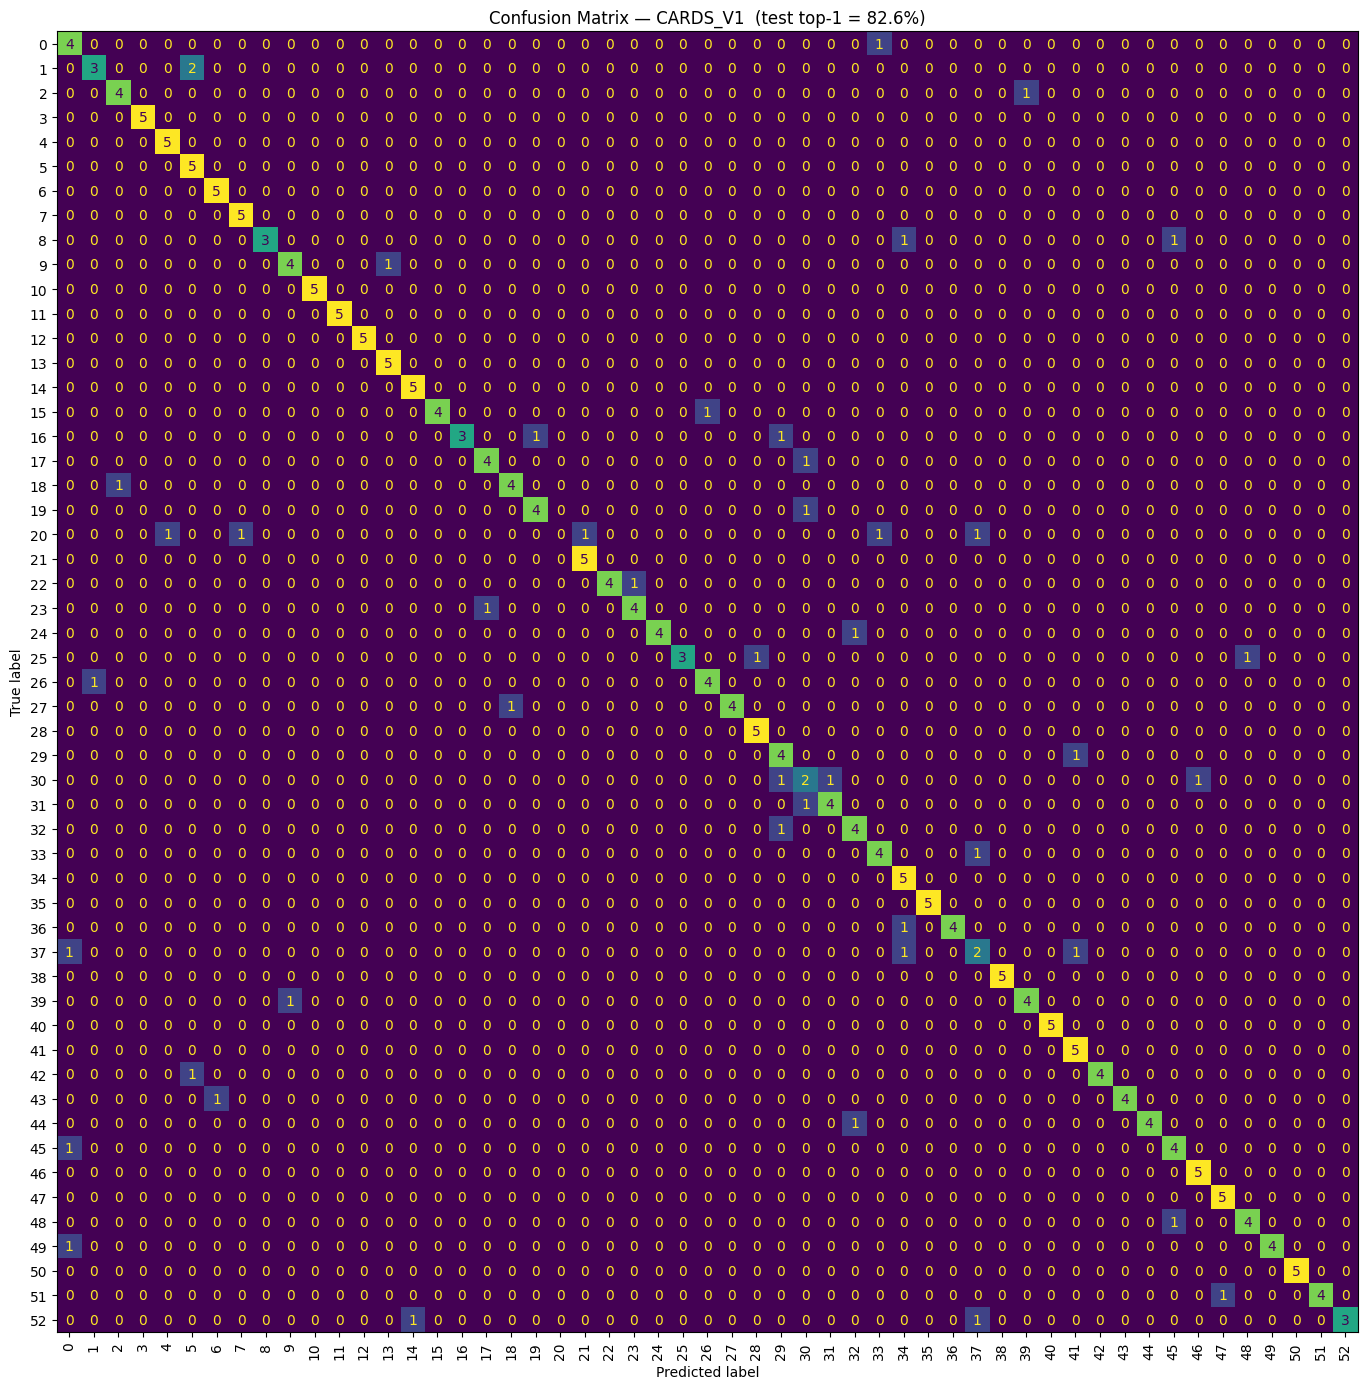

In [ ]:
# 4. Evaluate on test set — run exactly once
import torch
from torch.utils.data import DataLoader
from datasets.cards import get_cards
from models.augment_cnn import AugmentCNN
from genotypes import CARDS_V1

CHECKPOINT = '/content/drive/MyDrive/darts_experiments/augments/cards_augment_v1/best.pth.tar'
DATA_PATH  = './data/cards'
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Load checkpoint ---
ckpt = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
# El checkpoint puede ser el modelo directamente o un diccionario
if isinstance(ckpt, dict):
    cfg = ckpt['config']
    model = AugmentCNN(
        input_size=32,
        C_in=3,
        C=cfg.init_channels,
        n_classes=cfg.n_classes,
        n_layers=cfg.layers,
        auxiliary=False,
        genotype=CARDS_V1,
    ).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
else:
    # Es el modelo completo directamente
    model = ckpt
    if hasattr(model, 'module'):
        model = model.module  # quitar el wrapper DataParallel
    model = model.to(DEVICE)

# --- Parameter count ---
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Parameters: {n_params:.2f} M')

# --- Test loader ---
test_data, n_classes = get_cards(DATA_PATH, split='test')
test_loader = DataLoader(test_data, batch_size=128, shuffle=False,
                         num_workers=2, pin_memory=True)

# --- Evaluation loop ---
top1_correct = top5_correct = total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits, _ = model(images)

        pred1 = logits.argmax(dim=1)
        top1_correct += (pred1 == labels).sum().item()

        top5_preds = logits.topk(5, dim=1).indices
        top5_correct += sum(
            labels[i].item() in top5_preds[i].tolist()
            for i in range(labels.size(0))
        )

        total += labels.size(0)
        all_preds.extend(pred1.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

top1_acc = 100 * top1_correct / total
top5_acc = 100 * top5_correct / total
print(f'Test Top-1 accuracy : {top1_acc:.2f}%')
print(f'Test Top-5 accuracy : {top5_acc:.2f}%')
print(f'Total test samples  : {total}')

# --- Confusion matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax, colorbar=False, xticks_rotation='vertical')
plt.title(f'Confusion Matrix — CARDS_V1  (test top-1 = {top1_acc:.1f}%)')
plt.tight_layout()
cm_path = '/content/drive/MyDrive/darts_experiments/augments/cards_augment_v1/confusion_matrix.png'
plt.savefig(cm_path, dpi=150)
print(f'Saved → {cm_path}')
plt.show()